# 00 — The Big Picture: Control and Machine Learning

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What do controlling a dynamical system and training a learning machine have in common?*

This notebook is the map of the course: what the two fields are, where they meet, a dictionary between their vocabularies, and three examples that will return again and again.

### Table of Contents

1. **What the course connects** — three control problems, one learning problem, and the three formulas where they meet
2. **The map of the course** — the four parts, and the three threads running through them
3. **A minimal dictionary** — which control ↔ ML correspondences are exact, and which are only analogies
4. **How the notebooks are built** — the shared skeleton
5. **Three recurring examples** — the oscillator E1, the quadratic landscape E3, the point cloud E6
6. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

In [2]:
# RK4 integrator for x' = f(t, x) along the time grid ts (derived in notebook 13; a black box here)
def odeint(f, x0, ts):
    xs = [x0]
    for t, t1 in zip(ts[:-1], ts[1:]):
        x, h = xs[-1], t1 - t
        k1 = f(t, x)
        k2 = f(t + h / 2, x + h / 2 * k1)
        k3 = f(t + h / 2, x + h / 2 * k2)
        k4 = f(t + h, x + h * k3)
        xs.append(x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
    return torch.stack(xs)

## 1. What the course connects

**Idea.** Steering a state with a control and fitting parameters to data are two faces of one optimization problem along trajectories.

**Control.** A system has a *state* that evolves according to a law, the *state equation*, in which we can act through a *control*. The goal is to drive the state close to a desired one. Three questions organize the field:

- **optimal control:** which admissible control minimizes a cost, such as the distance to a target?
- **controllability:** can the state be driven *exactly* to a prescribed target?
- **stabilization / feedback:** can we find a rule $u=F(x)$, computed in real time from the state, that drives the system towards equilibrium?

**Machine learning.** A model with parameters $w$ is fitted to data by minimizing a loss $F(w)$, with the aim of making good predictions on *unobserved* data.

**Where they meet.** Place three formulas side by side:

$$
x'(t)=w(t)\,\sigma\big(a(t)\cdot x(t)+b(t)\big),\qquad
x_{k+1}=x_k+h\,w_k\,\sigma(a_k\cdot x_k+b_k),\qquad
f(x)\approx\sum_{j=1}^{K}w_j\,\sigma(a_j\cdot x+b_j).
$$

They are related, not identical. The first is a **controlled dynamical system** (a *neural ODE*): a neuron $w\,\sigma(a\cdot x+b)$ is used as the vector field, and the parameters $(w,a,b)$ act as controls. The second is one step of the explicit Euler method for it, and it is exactly the layer of a **residual neural network (ResNet)**. The third is a **shallow network**: it evaluates a sum of features at the *same* input $x$, so it is in general neither a composition of layers nor a trajectory. For the two dynamical models, training means choosing the controls that minimize a cost along the trajectories of the data points.

The course therefore runs along one line: first control (Part I), then optimization and adjoints (Part II), then machine learning (Part III), and finally the fusion of the two (Part IV) — with explainability, generalization, robustness and complexity as the goals of the fusion.

## 2. The map of the course

**Idea.** Four parts, one storyline; three threads tie them together.

```
CONTROL
  │  state + dynamics + control ................................. 01, 02
  │  controllability · observability · feedback ................. 02, 03, 04, 05
  │  optimization + adjoints .................................... 06, 07
  │  long horizons, gradient dynamics ........................... 06, 08
MACHINE LEARNING
  │  learning from data; training ≠ generalization .............. 09
  │  training algorithms: GD, SGD, momentum, Adam ............... 10, 11
NEURAL NETWORKS AS DYNAMICAL SYSTEMS
  │  shallow networks; ResNets = discretized controlled ODEs .... 12, 13
  │  classification as simultaneous control ..................... 14
  │  transformers · neural transport · diffusion ................ 15, 16, 17
CLOSING THE LOOP
  │  learning to control: reinforcement learning ................ 18
  │  synthesis: connections and limits .......................... 19
```

| Part | Notebooks |
|---|---|
| — | 00 *this map* |
| I. Control | [01 What is control?](01_control_fundamentals.ipynb) · [02 Linear control and the Kalman condition](02_linear_control_kalman.ipynb) · [03 Observability, duality and the construction of controls](03_observability_duality_adjoints.ipynb) · [04 Bang-bang and switching controls](04_bangbang_switching.ipynb) · [05 Feedback stabilization, LQR and MPC](05_feedback_stabilization.ipynb) |
| II. Optimization and long-time control | [06 Minimizers, gradient flows and gradient descent](06_variational_principles_gradient_flows.ipynb) · [07 Adjoint methods and the heat equation](07_adjoints_density_heat_control.ipynb) · [08 The turnpike property](08_long_time_control_turnpike.ipynb) |
| III. Machine learning | [09 Learning from data and generalization](09_machine_learning_foundations_generalization.ipynb) · [10 Training: gradient descent and SGD](10_training_gd_sgd.ipynb) · [11 Optimization algorithms: momentum and adaptive methods](11_optimization.ipynb) |
| IV. Networks as dynamical systems | [12 Shallow networks: representation and sparsity](12_shallow_networks.ipynb) · [13 ResNets and neural ODEs](13_neuralodes.ipynb) · 14 Classification as simultaneous control · [15 Transformers](15_transformers.ipynb) · 16 Neural transport · [17 Diffusion models](17_diffusion_models.ipynb) |
| V. Closing the loop | [18 Reinforcement learning](18_reinforcement_learning.ipynb) · 19 Control and learning: a synthesis |

Three threads run through the whole map:

- **adjoints:** Lagrange multipliers → adjoint system → adjoint method → backpropagation;
- **gradient dynamics:** gradient flow → gradient descent → stochastic gradient descent → momentum;
- **controllability → expressivity:** steering one system → steering many data points with one shared control.

## 3. A minimal dictionary

**Idea.** Some words translate exactly between the two fields; others only rhyme.

The table translates the basic words of control into machine learning. **"Exact"** means that, within the model stated in the last column, the two sides are the same mathematical object. **"Analogy"** means a useful parallel with a genuine difference, which is explained.

| Control | Machine learning | Status | In which model |
|---|---|---|---|
| state $x(t)$ | representation (feature vector) of a data point at depth $t$ | **exact** | neural ODE / ResNet: the data point is the initial state |
| control $u(t)$ | trainable parameters $(w(t),a(t),b(t))$ | **exact** | neural ODE |
| trajectory | forward propagation | **exact** | ResNet: the forward pass computes the Euler trajectory |
| time $t$ | depth | **exact**, with a caveat | ResNet with step $h$: layer $k$ ↔ time $kh$. In an Euler discretization every step is a layer, whether or not the weights are shared between steps. The number of time steps, the number of pieces on which the control is constant, and the number of independent parameter sets are three different counts |
| cost $J$ | loss (empirical risk) | **exact** | training written as minimizing a cost along trajectories |
| adjoint state | backward sensitivity (backpropagation) | **exact** as a mathematical identity | backpropagation is reverse-mode differentiation; its identity with a discrete adjoint system is shown in [notebook 03](03_observability_duality_adjoints.ipynb) and [notebook 13](13_neuralodes.ipynb) |
| target $x^1$ | desired prediction (label) | **analogy** | in classification the target is a *region* attached to each label, and the prediction is read off the final state; there is no single target point |
| feedback $u=F(x)$ | adaptive action, reinforcement learning | **analogy** | reinforcement learning is learning based on feedback through rewards ([notebook 18](18_reinforcement_learning.ipynb)); it learns a policy, which is not the same object as a feedback law designed from a known model |

Two warnings. First, the dictionary works because of one modelling choice, reading a network as a controlled ODE; it is not a statement about all of machine learning. Second, "training" adds an axis that the classical control framework of this course does not treat: the result must work on data *not* used to choose the controls (generalization, [notebook 09](09_machine_learning_foundations_generalization.ipynb)). Control theory has its own theories of robustness and uncertainty, which this course does not develop.

## 4. How the notebooks are built

**Idea.** One shared skeleton, so that you always know where you are.

- a title, an overview of the sections, and a short setup cell;
- sections that open with an **Idea** line stating in one sentence what the section adds;
- definitions, theorems and examples set off in quote blocks, with proofs as *Proof.* paragraphs ending in $\square$;
- the mathematics carries the argument; each code cell is the smallest runnable confirmation of it, and each figure is followed by an interpretation;
- **common misconceptions**, a short list of **key takeaways**, and **exercises**, graded ★ (conceptual), ★★ (mathematical) and ★★★ (computational);
- a short "**Where are we?** / **Where are we going?**" pair connecting each notebook to its neighbours, and references at the end.

Side material that would interrupt the main line goes into an appendix placed before the references.

## 5. Three recurring examples

**Idea.** Each notebook adds a new view of a familiar object instead of a new toy.

- **E1, the harmonic oscillator**, $x_1''+x_1=u$, with state $x=(x_1,x_2)=(\text{position},\text{velocity})$. It is controlled (02, 03), damped (01), stabilized by feedback (05) and optimized over long horizons (08); its closed loop under $u=-x_1-3x_2$ is learned from data (16).
- **E3, a quadratic landscape**, $J(u)=\tfrac12u^\top Qu-q^\top u$ with $Q$ symmetric positive definite. It is the simplest setting for gradient descent and its relatives (06, 10, 11). The functional that produces controls in notebook 03 is exactly of this form.
- **E6, a point cloud** of two classes in the plane. It is classified (09–11) and steered by neural ODEs (13–14). Further examples appear where they are needed: a one-dimensional regression set E9 (09, 12), toy tokens E7 (15), and a transported distribution E8 (16, 17).

The single computation of this notebook integrates two ODEs of the same form $x'=F(x,\text{control})$ — one classical, one borrowed from machine learning.

**Code and plot.** Left: E1 in the phase plane, free and with the damping feedback $u=-x_2$. Right: the E6 point cloud moved for one unit of time by the neuron field $x'=w\,\sigma(a\cdot x+b)$ with $\sigma(z)=\max\{z,0\}$ and fixed $(a,b,w)$.

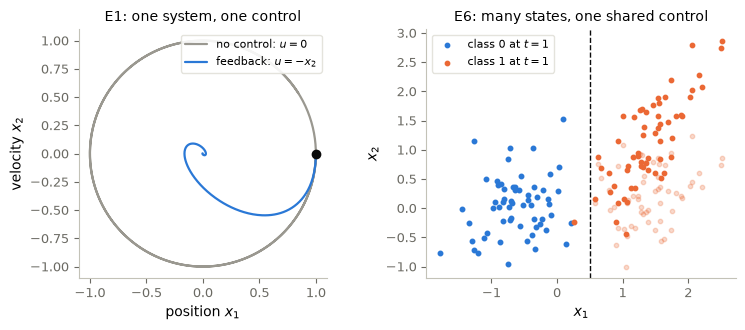

In [3]:
# E1: the harmonic oscillator x'' + x = u, free and with the damping feedback u = -x2
A = torch.tensor([[0.0, 1.0], [-1.0, 0.0]])
B = torch.tensor([[0.0], [1.0]])
x0 = torch.tensor([1.0, 0.0])
ts = torch.linspace(0, 12, 481)
free = odeint(lambda t, x: A @ x, x0, ts)
damped = odeint(lambda t, x: A @ x + B @ (-x[1:]), x0, ts)       # u = -x2

# E6: a two-class point cloud, every point moved by the SAME neuron field x' = w σ(a·x + b)
X = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
               torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])])
y = torch.cat([torch.zeros(60, dtype=torch.long), torch.ones(60, dtype=torch.long)])
a, b, w = torch.tensor([1.0, 0.0]), -0.5, torch.tensor([0.0, 1.0])
field = lambda t, Z: torch.relu(Z @ a + b)[:, None] * w          # many states, one shared control
X_end = odeint(field, X, torch.linspace(0, 1, 41))[-1]

fig, (ax1, ax2) = P.panels(2, size=(3.9, 3.4))
P.phase(ax1, [free, damped], labels=["no control: $u=0$", "feedback: $u=-x_2$"],
        colors=[P.GREY, P.BLUE], start=x0, equal=True,
        xlabel="position $x_1$", ylabel="velocity $x_2$", title="E1: one system, one control")
for cls, color in ((0, P.BLUE), (1, P.ORANGE)):
    ax2.scatter(*X[y == cls].T, s=10, color=color, alpha=0.25)
    ax2.scatter(*X_end[y == cls].T, s=10, color=color, label=f"class {cls} at $t=1$")
ax2.axvline(0.5, color=P.INK, lw=1, ls="--")
P.label(ax2, "$x_1$", "$x_2$", title="E6: many states, one shared control")
plt.show()

*Left:* E1 in the phase plane from $x^0=(1,0)$. Without control the energy $\tfrac12|x|^2$ is conserved and the trajectory is a circle. With the feedback $u=-x_2$ the state spirals into the equilibrium. *Right:* the E6 point cloud (faint: initial positions; solid: positions at $t=1$) under the field $x'=w\,\sigma(a\cdot x+b)$ with $a=(1,0)$, $b=-0.5$, $w=(0,1)$.

The ReLU activates the half-plane $a\cdot x+b>0$, to the right of the dashed line, and freezes the other one: only the points on the right move, in the direction $w$, faster the farther they are from the line. The left panel is the classical situation of control — one system, steered by its own control (notebooks 01–05). The right panel is the situation of machine learning read as control: **many states, one shared control**. Classification by such elementary moves is the subject of notebook 14.

## 6. Exercises

1. **Exact or analogy? ★** Decide whether each correspondence is exact or only an analogy, and say in which model: (a) learning rate ↔ time step of a gradient flow; (b) training set ↔ set of initial states; (c) regularization term $\alpha\int_0^T\|(a,w,b)\|^2dt$ ↔ cost of the control.
2. **Which problem is it? ★** Classify each task as optimal control, controllability, stabilization, or a learning problem (supervised, unsupervised, reinforcement): (a) a thermostat keeps a room at 21 °C; (b) a satellite must reach a given orientation at a given time; (c) a drone must reach a point while using as little energy as possible; (d) a program learns to play a game from wins and losses; (e) a program learns to recognize handwritten digits from labelled examples.
3. **Finding your way. ★** Using the map in §2, which notebook would you open first to answer: (a) "When can a linear system be steered anywhere?"; (b) "Why can more damping make a system return to rest *more slowly*?"; (c) "Why does an adjoint system appear when we construct controls?"

## Where are we going?

[Notebook 01](01_control_fundamentals.ipynb) starts the mathematics. It makes the three control problems of §1 precise, introduces feedback, and meets the first surprise of the course: more damping does not always mean faster return to rest.

## References

1. W. E, [*A proposal on machine learning via dynamical systems*](https://doi.org/10.1007/s40304-017-0103-z), Communications in Mathematics and Statistics **5** (2017), 1–11.
2. E. Haber, L. Ruthotto, [*Stable architectures for deep neural networks*](https://doi.org/10.1088/1361-6420/aa9a90), Inverse Problems **34** (2018), 014004.
3. D. Ruiz-Balet, E. Zuazua, [*Neural ODE control for classification, approximation, and transport*](https://doi.org/10.1137/21M1411433), SIAM Review **65** (2023), 735–773.
4. B. Geshkovski, E. Zuazua, [*Turnpike in optimal control of PDEs, ResNets, and beyond*](https://doi.org/10.1017/S0962492922000046), Acta Numerica **31** (2022), 135–263.